In [1]:
# Python 3.10.11
!pip install -r requirements.txt > /dev/null
from args import *

In [2]:
import scanpy as sc
import omicverse as ov
import matplotlib.pyplot as plt
ov.plot_set()


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.8, Tutorials: https://omicverse.readthedocs.io/
Dependency error: The 'scrublet>=0.2' distribution was not found and is required by the application


In [3]:
import pandas as pd
import os

In [4]:
with open(valid_gene_file_path, "r") as f:
    gene_df = pd.read_csv(f, index_col=0)

In [5]:
df_list = []
for root, _, files in os.walk(data_input_dir_path / "gene_20115/sub_module"):

    for file in files:
        if not file.endswith(".csv") or file == "1.csv":
            continue
        file_path = os.path.join(root, file)
        _df = pd.read_csv(file_path, index_col=0)
        df_list.append(_df)

In [6]:
gene_df = pd.concat(df_list, axis=0)

In [7]:
gene_df.head()

,TCGA-EA-A3HT-01,TCGA-FU-A3HZ-01,TCGA-FU-A3TQ-01,TCGA-DS-A0VK-01,TCGA-UC-A7PG-01,TCGA-C5-A7UE-01,TCGA-C5-A1MJ-01,TCGA-UC-A7PI-01,TCGA-C5-A1MF-01,TCGA-EA-A5ZF-01,...,TCGA-JW-A5VI-01,TCGA-VS-A9UD-01,TCGA-C5-A1BQ-01,TCGA-MU-A8JM-01,TCGA-DS-A0VM-01,TCGA-MY-A5BF-01,TCGA-EA-A556-01,TCGA-IR-A3LA-01,TCGA-VS-AA62-01,TCGA-ZJ-AAXB-01
sample,,,,,,,,,,,,,,,,,,,,,
ZNF660,2.9358,2.9508,1.8157,1.2883,0.5638,0.0000,2.6537,1.6890,0.0000,2.7553,...,2.3468,0.0000,0.7254,0.8913,1.1255,0.5435,4.0806,1.2783,1.5866,1.5871
SULT1C4,2.4924,6.2827,2.8401,3.2712,2.2708,0.6365,4.5379,2.9398,1.3127,5.2155,...,2.7960,1.4617,1.2059,2.6156,1.3087,1.9049,5.4886,3.7520,3.2502,1.0017
ITGA9,5.3442,4.9417,4.0109,4.4379,4.8687,1.9158,6.2904,3.0078,2.7942,5.3230,...,3.2549,4.7246,3.0898,3.1891,2.9626,3.4069,6.4646,7.5797,4.4943,3.7034
THSD7A,2.5647,1.6977,2.4543,4.4055,1.5425,0.6365,4.9742,3.1350,0.0000,3.8637,...,3.0107,2.1727,0.4078,2.1438,2.1844,1.7169,7.0676,2.6658,3.7028,1.0017
SNED1,7.8584,5.5020,7.1253,6.7895,5.8317,5.0517,8.7745,7.3683,6.3942,8.3613,...,6.8510,6.0036,6.1144,6.3232,5.6366,5.2672,8.8880,5.8496,7.4161,6.2320


In [8]:
from statsmodels import robust #import package
gene_mad=gene_df.apply(robust.mad) #use function to calculate MAD
gene_df=gene_df.T
gene_df=gene_df.loc[gene_mad.sort_values(ascending=False).index[:2000]]

In [9]:
gene_df.head()

sample,ZNF660,SULT1C4,ITGA9,THSD7A,SNED1,DCHS1,ZNF423,EPDR1,SALL1,EMX2,...,NDUFS5,MRPS15,SNRPD2,COX6B1,POLR2I,C12orf10,SNRPA,SNRPE,ATP5G1,ATP5G2
TCGA-JW-A852-01,0.0,0.0000,1.6239,0.0000,4.8460,6.6272,2.1603,3.2216,1.2558,2.1603,...,12.5719,11.4672,13.4841,13.7007,11.0246,10.5634,12.3427,11.0369,11.9509,13.0910
TCGA-JW-A5VK-01,0.0,0.9279,1.8905,0.0000,7.0330,6.9978,2.2048,2.9577,1.2350,1.4881,...,12.5462,11.9964,12.2605,13.6459,11.1464,10.4769,11.6695,10.8626,11.7326,12.9509
TCGA-Q1-A5R3-01,0.0,0.4584,0.0000,1.5211,5.5887,5.6329,1.6978,3.8544,3.6112,3.7379,...,12.9323,11.5472,14.1187,14.3383,11.2394,10.3380,11.8468,11.2332,12.1945,13.2541
TCGA-EK-A2RB-01,0.0,0.0000,2.7911,1.5724,5.9309,6.1869,3.3334,2.8712,2.1868,1.3669,...,12.6316,11.3724,12.6566,13.1176,10.0285,10.1913,11.4384,10.3476,11.4301,12.8904
TCGA-EA-A5O9-01,0.0,0.4865,1.5873,0.8495,3.9481,6.3145,2.3247,3.1074,2.4358,2.5389,...,12.2233,11.2864,12.5636,12.8312,10.0690,10.6356,11.6087,10.6583,10.3524,12.7798


In [10]:
#import PyWGCNA
pyWGCNA_5xFAD = ov.bulk.pyWGCNA(name='5xFAD_2k', 
                              species='mus musculus', 
                              geneExp=gene_df, 
                              save=True,
                              outputPath=str(data_output_dir_path) + "/", 
                              figureType='png')
pyWGCNA_5xFAD.geneExpr.to_df().head(5)

Saving data to be True, checking requirements ...
Figure directory does not exist!
Creating figure directory!


sample,ZNF660,SULT1C4,ITGA9,THSD7A,SNED1,DCHS1,ZNF423,EPDR1,SALL1,EMX2,...,NDUFS5,MRPS15,SNRPD2,COX6B1,POLR2I,C12orf10,SNRPA,SNRPE,ATP5G1,ATP5G2
TCGA-JW-A852-01,0.0,0.0000,1.6239,0.0000,4.8460,6.6272,2.1603,3.2216,1.2558,2.1603,...,12.5719,11.4672,13.4841,13.7007,11.0246,10.5634,12.3427,11.0369,11.9509,13.0910
TCGA-JW-A5VK-01,0.0,0.9279,1.8905,0.0000,7.0330,6.9978,2.2048,2.9577,1.2350,1.4881,...,12.5462,11.9964,12.2605,13.6459,11.1464,10.4769,11.6695,10.8626,11.7326,12.9509
TCGA-Q1-A5R3-01,0.0,0.4584,0.0000,1.5211,5.5887,5.6329,1.6978,3.8544,3.6112,3.7379,...,12.9323,11.5472,14.1187,14.3383,11.2394,10.3380,11.8468,11.2332,12.1945,13.2541
TCGA-EK-A2RB-01,0.0,0.0000,2.7911,1.5724,5.9309,6.1869,3.3334,2.8712,2.1868,1.3669,...,12.6316,11.3724,12.6566,13.1176,10.0285,10.1913,11.4384,10.3476,11.4301,12.8904
TCGA-EA-A5O9-01,0.0,0.4865,1.5873,0.8495,3.9481,6.3145,2.3247,3.1074,2.4358,2.5389,...,12.2233,11.2864,12.5636,12.8312,10.0690,10.6356,11.6087,10.6583,10.3524,12.7798


Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..



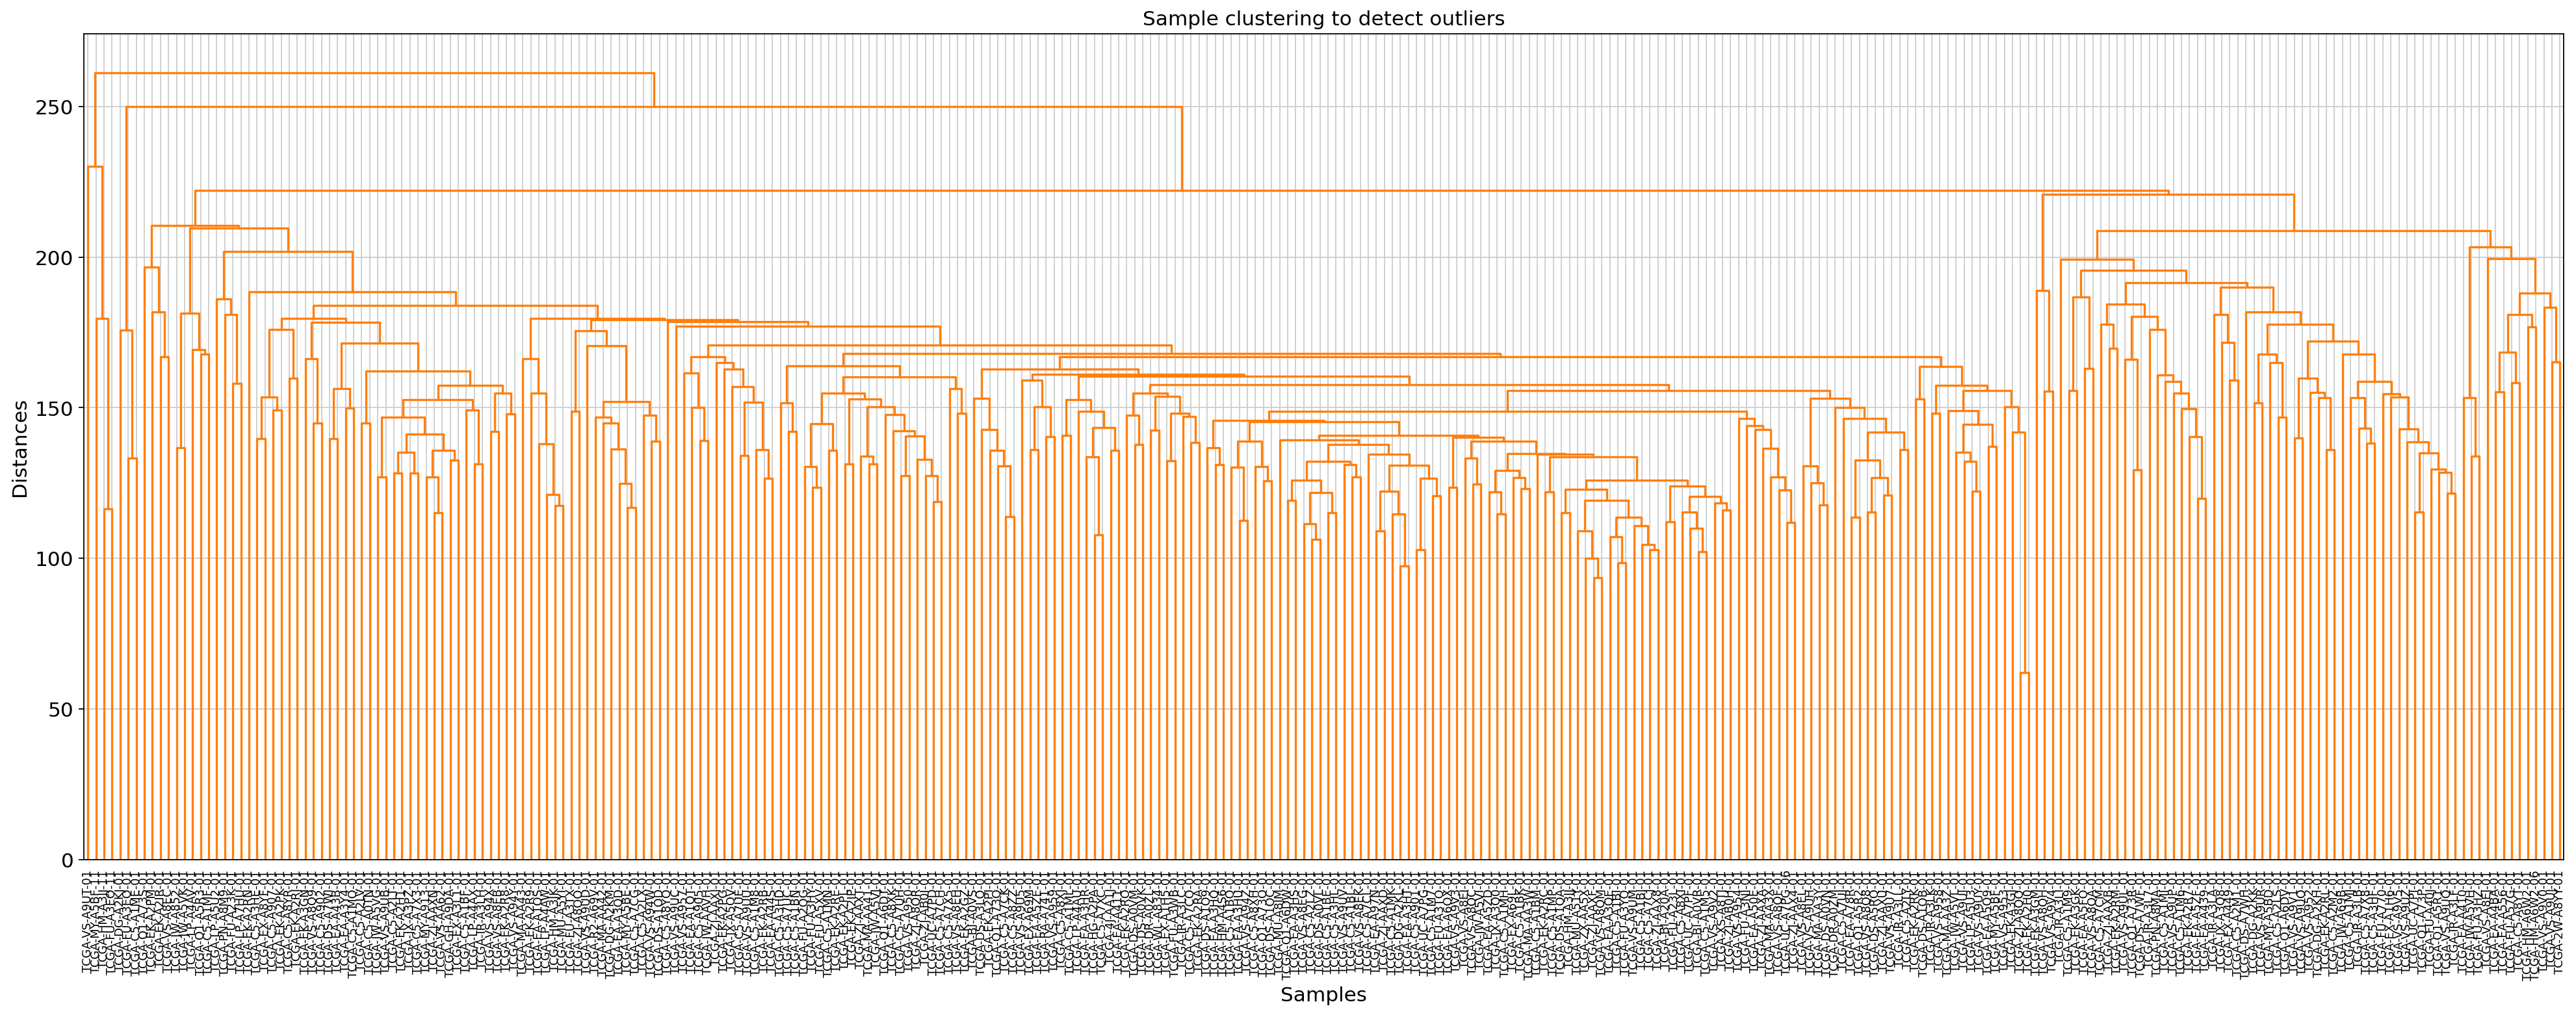

In [11]:
pyWGCNA_5xFAD.preprocess()

Run pyWGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  3843
    Power  SFT.R.sq     slope truncated R.sq      mean(k)    median(k)  \
0       1  0.011504  0.373217       0.985247  1019.588075  1001.257051   
1       2  0.433706 -1.802329        0.98809   271.463626   251.107167   
2       3  0.769981 -2.489082       0.995987    93.139344    77.591829   
3       4  0.857522 -2.420288       0.982735    38.074012    27.160463   
4       5  0.942319 -2.092529       0.989044    17.800267    10.418245   
5       6  0.962356 -1.979073       0.991078     9.269459     4.339622   
6       7  0.961061 -1.895438       0.984349     5.272061     1.940222   
7       8  0.966549 -1.794474       0.988393     3.223728     0.925433   
8       9  0.964621 -1.722752       0.984927     2.091929     0.471163   
9      10  0.968528 -1.653881       0.988989     1.425283     0.245844   
10     11   0.96995 -1.598711        0.98862     1.010731     0.133674   
11     

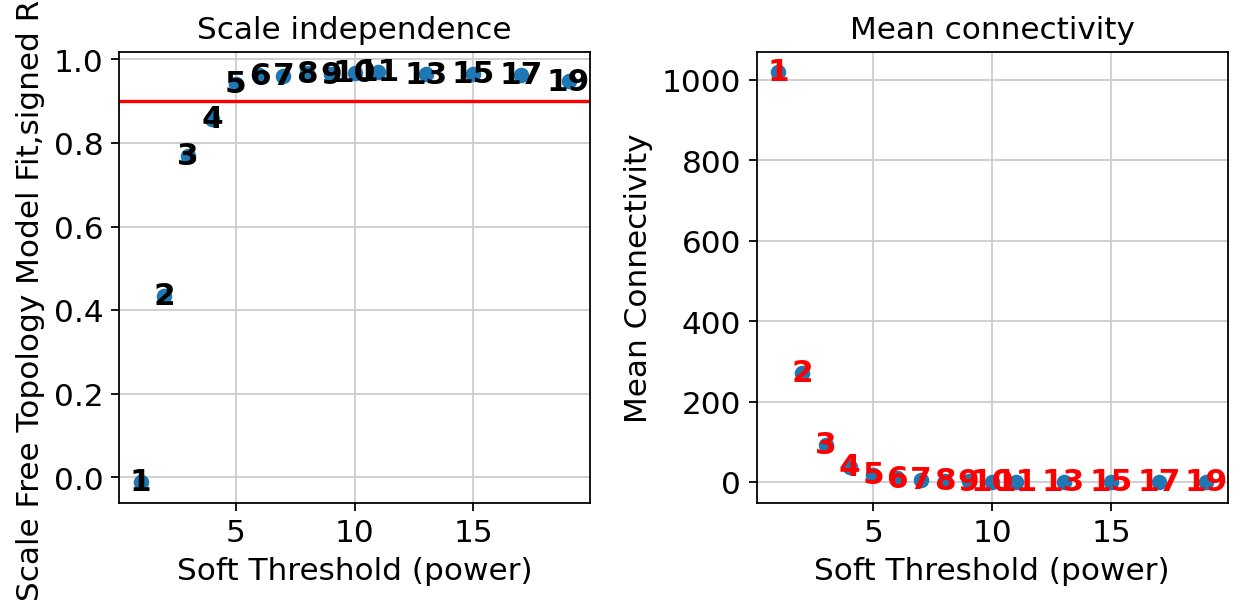

In [12]:
pyWGCNA_5xFAD.calculate_soft_threshold()

In [13]:
pyWGCNA_5xFAD.calculating_adjacency_matrix()

calculating adjacency matrix ...
	Done..



In [14]:
pyWGCNA_5xFAD.calculating_TOM_similarity_matrix()

calculating TOM similarity matrix ...
	Done..



Going through the merge tree...
..cutHeight not given, setting it to 0.9978440736509663  ===>  99% of the (truncated) height range in dendro.
..done.
Calculating 34 module eigengenes in given set...
	Done..

mergeCloseModules: Merging modules whose distance is less than 0.2
fixDataStructure: data is not a Dictionary: converting it into one.
multiSetMEs: Calculating module MEs.
  Working on set 1 ...
Calculating 34 module eigengenes in given set...
	Done..

multiSetMEs: Calculating module MEs.
  Working on set 1 ...
Calculating 30 module eigengenes in given set...
	Done..

multiSetMEs: Calculating module MEs.
  Working on set 1 ...
Calculating 29 module eigengenes in given set...
	Done..

multiSetMEs: Calculating module MEs.
  Working on set 1 ...
Calculating 28 module eigengenes in given set...
	Done..

multiSetMEs: Calculating module MEs.
  Working on set 1 ...
Calculating 27 module eigengenes in given set...
	Done..

  Calculating new MEs...
multiSetMEs: Calculating module MEs.
  Wor

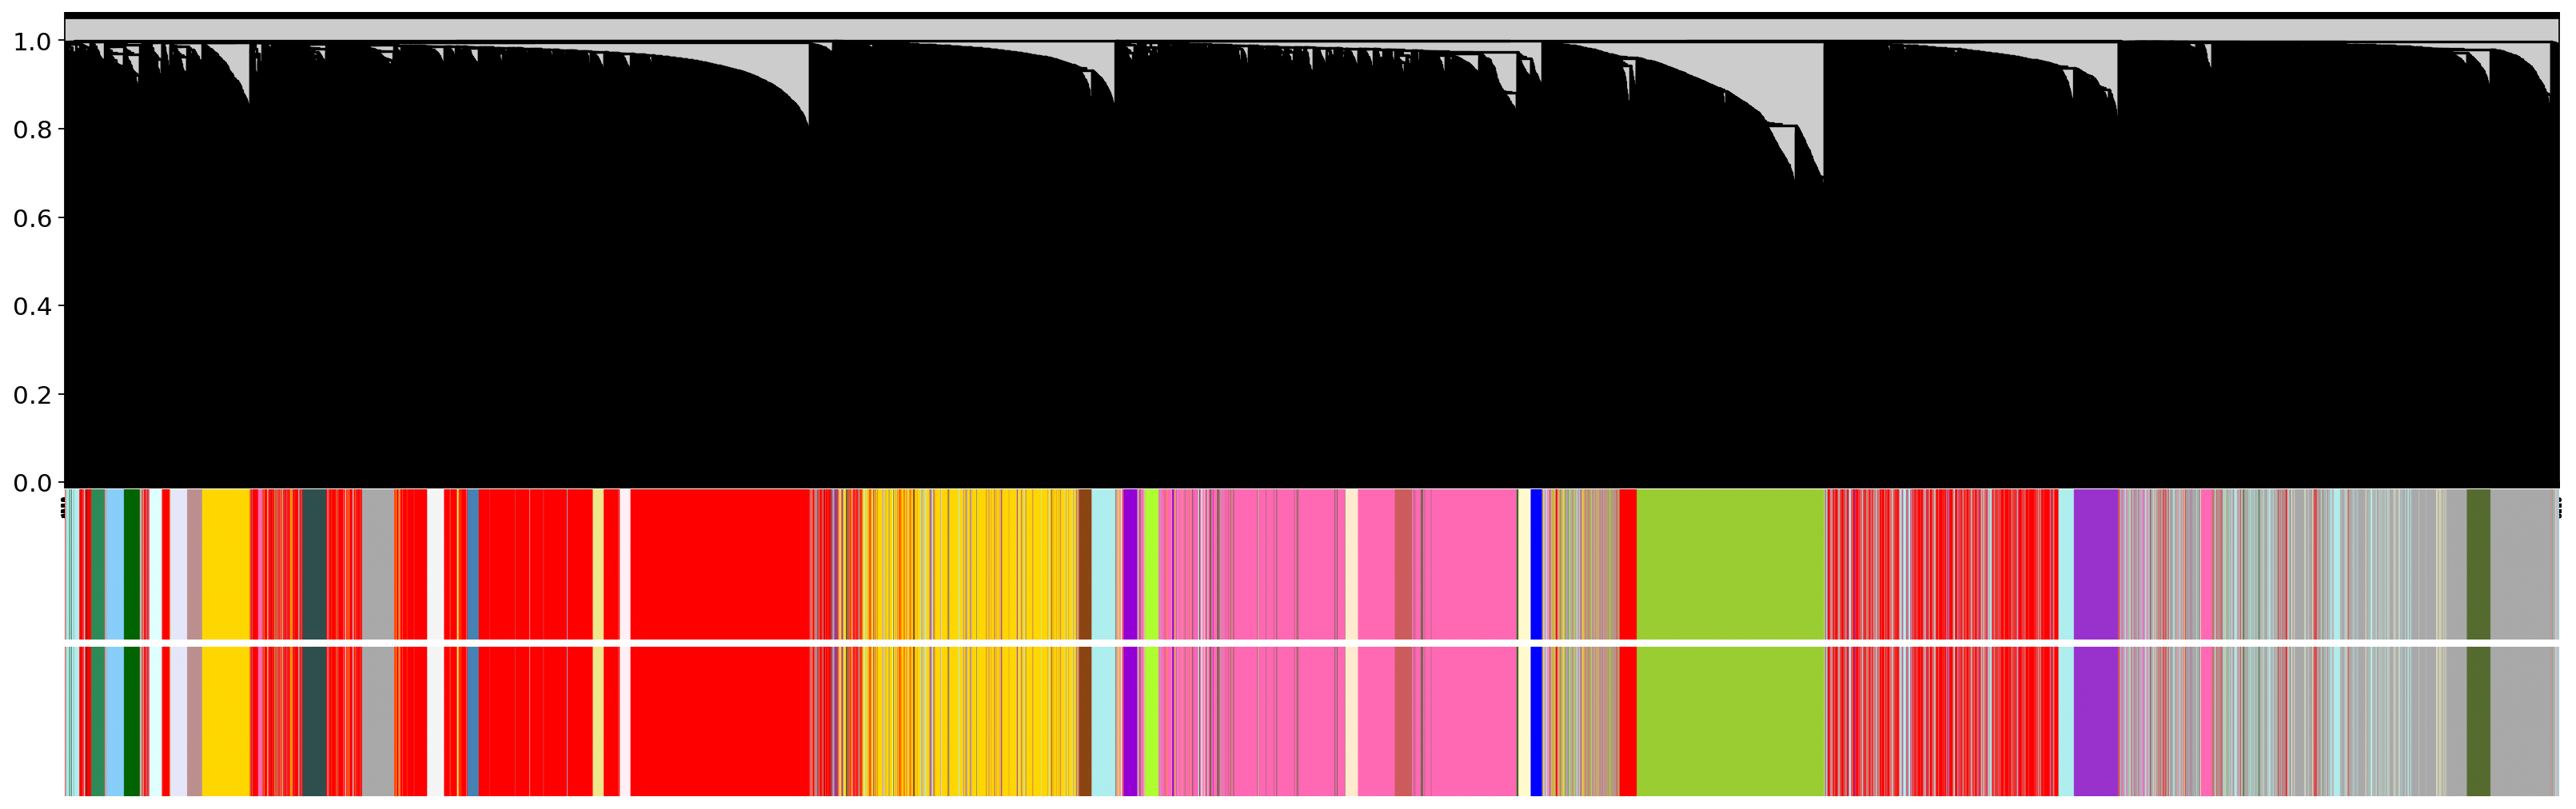

In [15]:
pyWGCNA_5xFAD.calculate_geneTree()
pyWGCNA_5xFAD.calculate_dynamicMods(kwargs_function={'cutreeHybrid': {'deepSplit': 2, 'pamRespectsDendro': False}})
pyWGCNA_5xFAD.calculate_gene_module(kwargs_function={'moduleEigengenes': {'softPower': 5}})

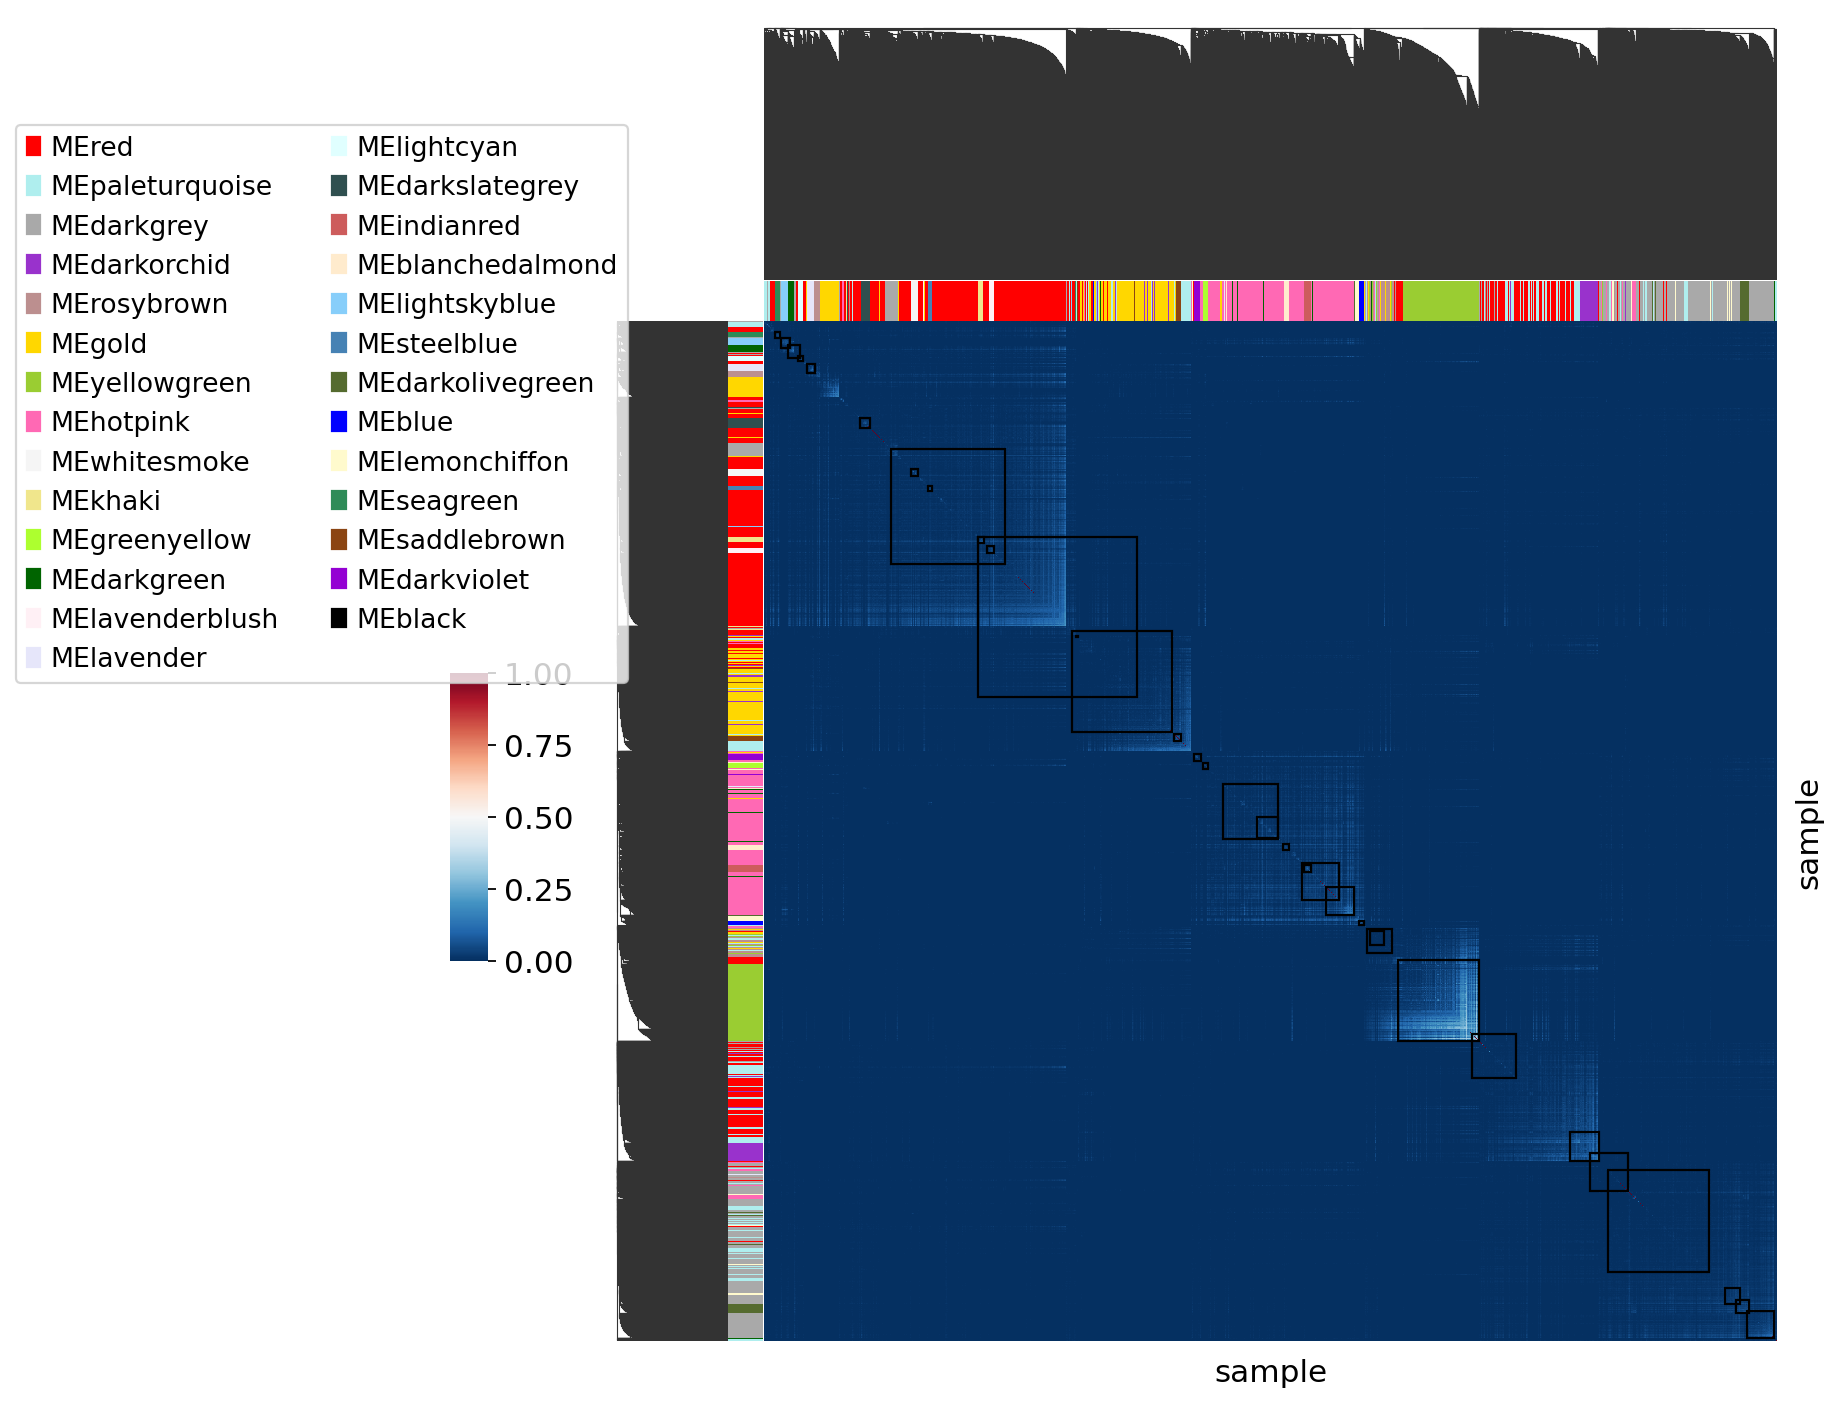

In [16]:
pyWGCNA_5xFAD.plot_matrix(save=True)

In [17]:
pyWGCNA_5xFAD.saveWGCNA()

Saving WGCNA as 5xFAD_2k.p
